# Executive Summary

## Project Objective
The goal of this project is to analyze the Global Superstore dataset and uncover business insights related to sales, profit, customers, products, discounts, markets, and regional performance.

## Key Questions
- Which markets generate the highest sales and profit?
- Which product categories and sub-categories perform best?
- How are discount levels associated with profitability?
- Which customers contribute the most sales and profit?
- Which products, countries, and regions require further investigation?

## Key Findings
- Technology generated the highest total profit among the three product categories.
- Tables was the only sub-category with negative total profit in this analysis.
- Higher discount levels are associated with lower aggregate profit in the dataset; this is an observed relationship, not proof of causation.
- The United States generated the highest total sales and total profit among countries in the dataset.
- APAC generated the highest aggregate sales and profit among the listed markets.

## Recommendations
- Review loss-making sub-categories, especially Tables, to understand pricing, discount, and cost drivers.
- Investigate high-discount transactions and evaluate whether discount levels are consistent with profitable sales.
- Evaluate customers using both sales and profit rather than revenue alone.
- Compare markets using both absolute profit and profit margin before making resource-allocation decisions.

## Project Objective

The objective of this project is to analyze sales, profit, customers, products, and regional performance using the Global Superstore dataset. The goal is to identify business trends, uncover key insights, and understand factors that influence sales and profitability.

## Import libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [75]:
df = pd.read_csv('/kaggle/input/datasets/fatihilhan/global-superstore-dataset/superstore.csv')

df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


## Dataset understanding

In [76]:
df.shape

(51290, 27)

In [77]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [78]:
df.dtypes

Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
记录数                 int64
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [80]:
df.isna().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [83]:
# Checking unique values in all important categorical columns
categorical_cols = ['Category', 'Segment', 'Market', 'Ship.Mode', 'Order.Priority']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

# Extra useful counts
print(f"\nTotal unique Sub-Categories : {df['Sub.Category'].nunique()}")
print(f"Total unique Countries       : {df['Country'].nunique()}")
print(f"Total unique Cities          : {df['City'].nunique()}")
print(f"Total unique Products        : {df['Product.Name'].nunique()}")
print(f"Total unique Customers       : {df['Customer.Name'].nunique()}")


--- Category ---
Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

--- Segment ---
Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64

--- Market ---
Market
APAC      11002
LATAM     10294
EU        10000
US         9994
EMEA       5029
Africa     4587
Canada      384
Name: count, dtype: int64

--- Ship.Mode ---
Ship.Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

--- Order.Priority ---
Order.Priority
Medium      29433
High        15501
Critical     3932
Low          2424
Name: count, dtype: int64

Total unique Sub-Categories : 17
Total unique Countries       : 147
Total unique Cities          : 3636
Total unique Products        : 3788
Total unique Customers       : 795


### Insight

The dataset covers a wide range of business dimensions:

- 3 Product Categories: Office Supplies (most orders), Technology, Furniture
- 3 Customer Segments: Consumer, Corporate, Home Office
- 7 Markets: APAC has the most orders, Canada the least
- 4 Shipping Modes: Standard Class is most used, Same Day is least used
- 4 Order Priorities: Medium is most common, Low is least common
- 17 Sub-Categories, 3,636 unique cities, and orders from multiple countries

This gives us a complete picture of the dataset before starting analysis.

In [84]:
# Investigating the unknown Chinese column: 记录数
print("Column name       :", '记录数')
print("What it means     : 'Number of Records' in Chinese")
print("Unique values     :", df['记录数'].unique())
print("Value counts      :")
print(df['记录数'].value_counts())

# Since every row has value = 1, this column adds no analytical value
# Renaming it first so we can reference it cleanly, then dropping it
df.rename(columns={'记录数': 'Record.Count'}, inplace=True)
df.drop(columns=['Record.Count'], inplace=True)

print("\n记录数 column has been renamed and dropped.")
print("Updated shape:", df.shape)

Column name       : 记录数
What it means     : 'Number of Records' in Chinese
Unique values     : [1]
Value counts      :
记录数
1    51290
Name: count, dtype: int64

记录数 column has been renamed and dropped.
Updated shape: (51290, 26)


### Insight

The dataset contained a column named 记录数, a Chinese term meaning 
"Number of Records". On inspection, every single row in this column 
had the value 1 — meaning it simply counts each row as one record.

Since this column provides zero analytical value, it has been identified, 
explained, and removed. The dataset now has 26 columns instead of 27.

This is an important data cleaning step — unknown or irrelevant columns 
should always be investigated and handled before analysis begins.

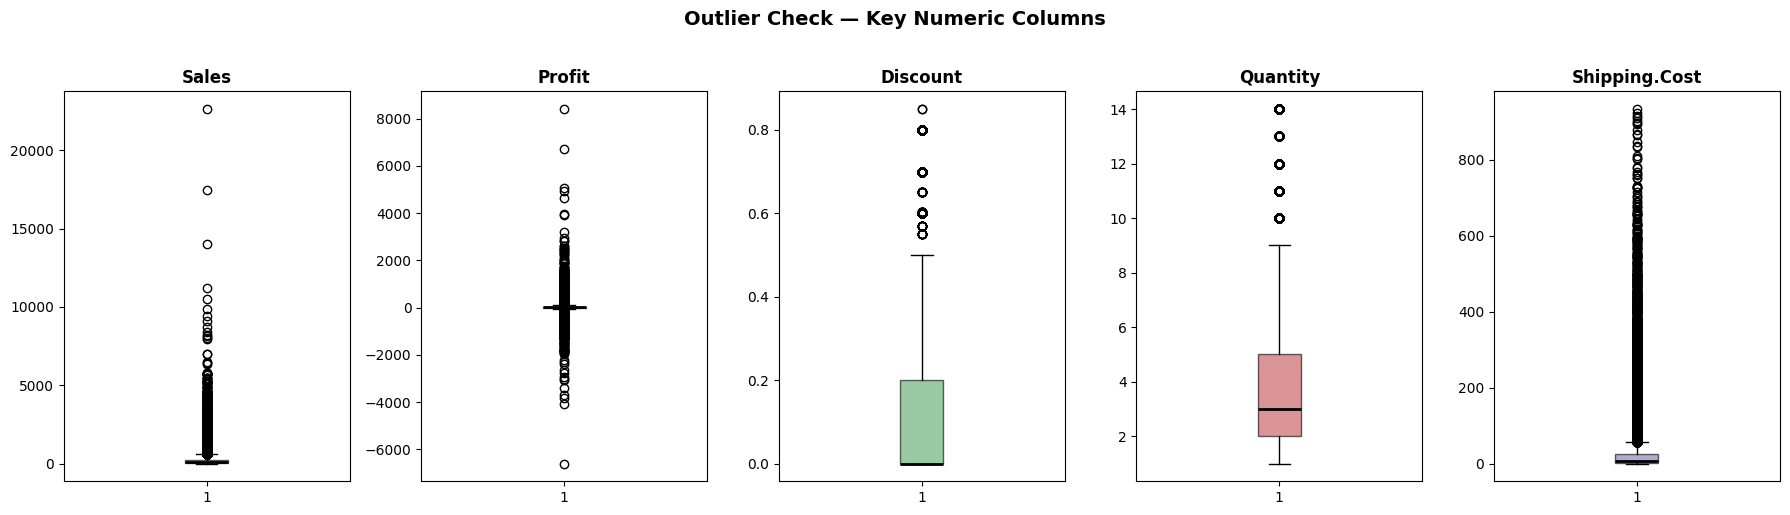


=== Outlier Count per Column (IQR method) ===
Sales                :  5655 outlier rows
Profit               :  9755 outlier rows
Discount             :  4172 outlier rows
Quantity             :   877 outlier rows
Shipping.Cost        :  5909 outlier rows


In [85]:
# Checking for outliers in key numeric columns using boxplots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

cols_to_check = ['Sales', 'Profit', 'Discount', 'Quantity', 'Shipping.Cost']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, (col, color) in enumerate(zip(cols_to_check, colors)):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Outlier Check — Key Numeric Columns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Printing outlier counts using IQR method
print("\n=== Outlier Count per Column (IQR method) ===")
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col:20s} : {len(outliers):>5} outlier rows")

### Insight

Outlier analysis using the IQR method revealed the following:

- Sales        : 5,655 outlier rows — a few very large orders exist
- Profit       : 9,755 outlier rows — both large profits and large losses exist
- Discount     : outliers present at high discount levels (above 60-70%)
- Quantity     : relatively fewer outliers
- Shipping.Cost: some unusually high shipping costs exist

Important note: These outliers are NOT removed. They represent real business 
orders — large bulk purchases, premium customers, and high-discount sales. 
Removing them would cause us to lose genuine business information.

We will keep them and account for them during deeper analysis.

### Insight

The Global Superstore dataset contains sales, profit, customer, product, and regional information. The dataset includes both numerical and categorical features, making it suitable for business analysis and insight generation.

Also the dataset does not contain any missing values. All columns are complete, which improves data quality and reduces the need for additional preprocessing before analysis.

# KPI Dashboard

In [86]:
# KPI Dashboard

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order.ID'].nunique()
total_customers = df['Customer.ID'].nunique()
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $12,642,905.00
Total Profit: $1,467,457.29
Total Orders: 25035
Total Customers: 4873
Profit Margin: 11.61%


### KPI Insights

- The business generated total sales of $12,642,905.00.
- Total profit reached $1,467,457.29.
- Total orders 25035
- The company served 4873 unique customers.
- Profit margin was 11.61%, indicating overall business profitability.

# Monthly Sales Trend Analysis

## Data Quality Assessment

The Order Date and Ship Date columns are stored as text (object data type). They need to be converted to datetime format before performing time-based analysis.

In [87]:
df["Order.Date"] = pd.to_datetime(df["Order.Date"])
df["Ship.Date"] = pd.to_datetime(df["Ship.Date"])
df

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07,CA-2011-130813,High,...,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21,CA-2011-148614,Medium,...,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,...,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,...,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29,CA-2011-146969,High,...,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,2014-12-03,CA-2014-109701,High,...,69,Corporate,2014-12-04,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,2014-12-03,CA-2014-109701,High,...,9,Corporate,2014-12-04,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,2014-12-18,CA-2014-106964,Medium,...,12,Home Office,2014-12-21,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,2014-12-25,CA-2014-145219,Critical,...,90,Home Office,2014-12-26,First Class,15.95,California,Binders,2014,North America,52


The Global Superstore dataset can be trusted for business analysis because it contains no missing values and no duplicate records. The dataset includes important business metrics such as Sales, Profit, Quantity, Discount, Customer, Product, and Date information, making it suitable for analyzing business performance and identifying key insights.

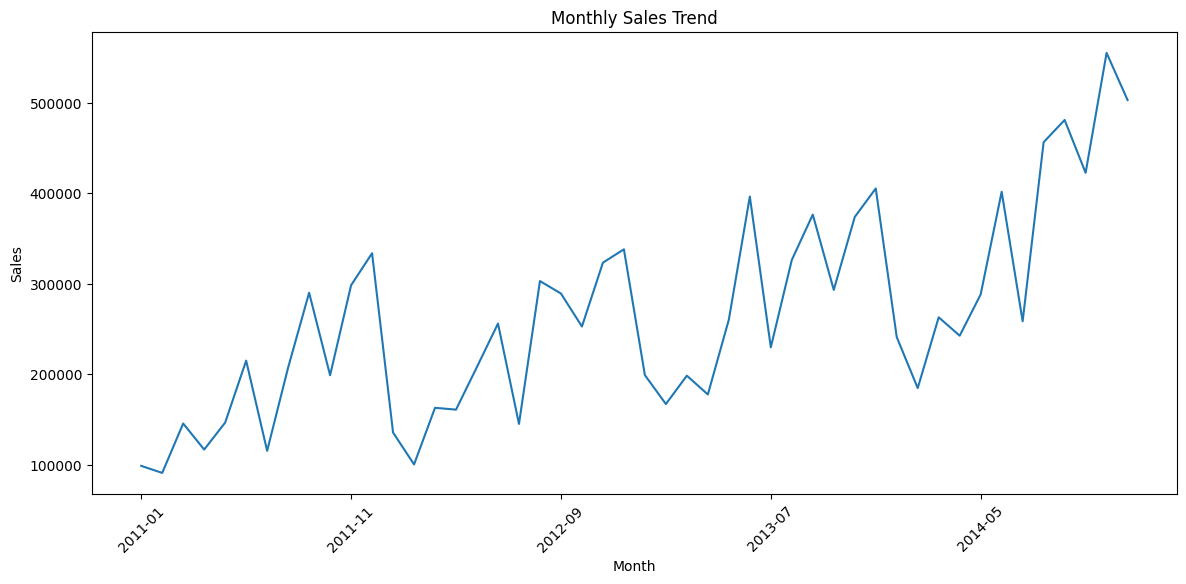

In [88]:
monthly_sales = (
    df.groupby(df['Order.Date'].dt.to_period('M'))['Sales']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))
monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)

plt.show()

### Insights

- Sales fluctuate across different months.
- Several months show noticeable sales peaks.
- Overall sales appear to increase over time.
- Certain periods may indicate seasonal demand.

# Monthly Profit Trend Analysis

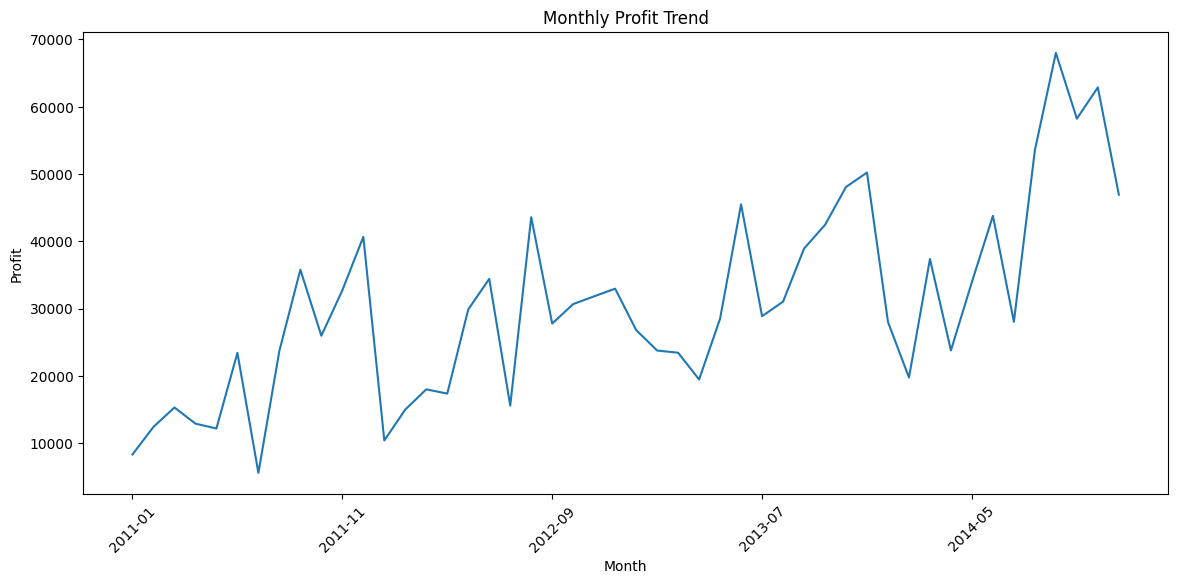

In [89]:
monthly_profit = (
    df.groupby(df['Order.Date'].dt.to_period('M'))['Profit']
    .sum()
)

monthly_profit.index = monthly_profit.index.astype(str)

plt.figure(figsize=(14,6))
monthly_profit.plot()

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)

plt.show()

### Insights

- Profit changes significantly across months.
- Some months generate strong profits while others decline.
- Profit growth does not always match sales growth.
- Seasonal factors may influence profitability.

### Insight

The dataset has good data quality with no missing values and no duplicate records. The date columns are available for time-based analysis, and the dataset contains key business metrics required for sales, profit, customer, and regional analysis. Therefore, the data is ready for further business analysis.

# Top 10 Products by Sales

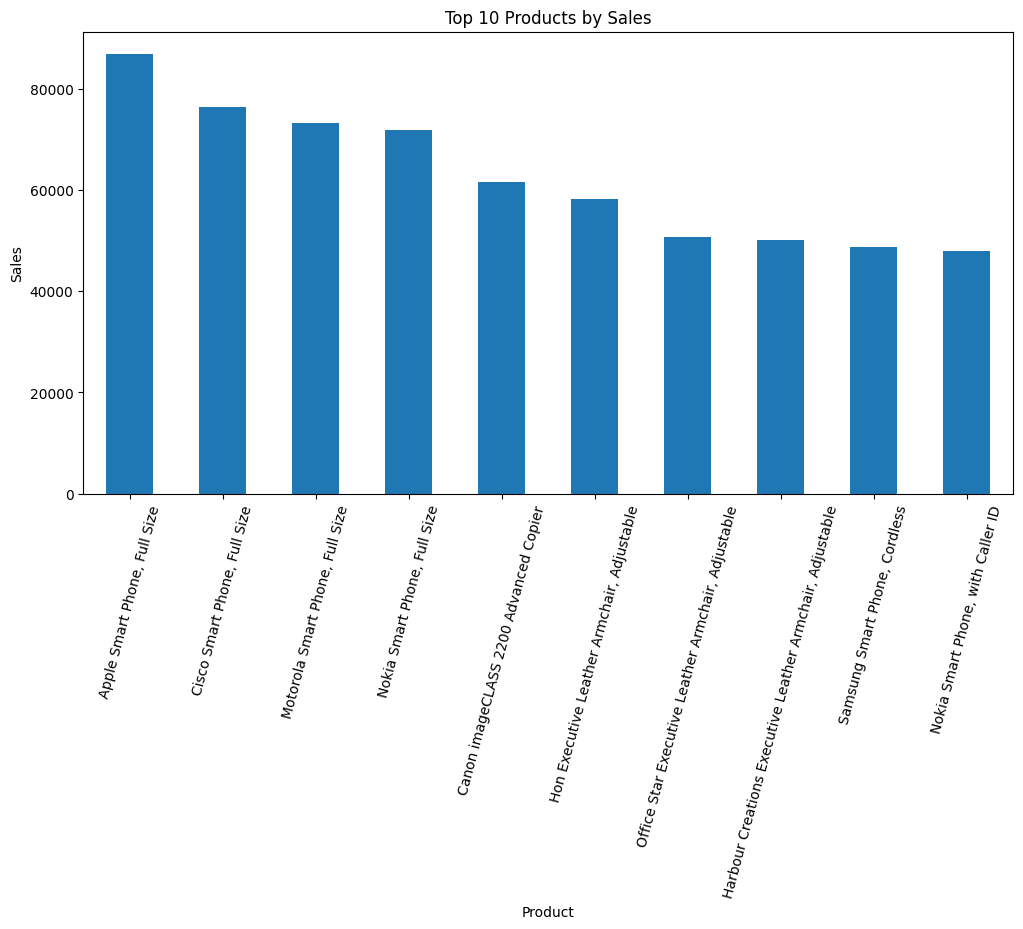

In [90]:
top_sales_products = (
    df.groupby('Product.Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_sales_products.plot(kind='bar')

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Sales')

plt.xticks(rotation=75)
plt.show()

### Insights

- The top 10 products contribute a significant share of total sales.
- Some products clearly outperform others in revenue generation.
- These products should be prioritized for inventory and marketing efforts.

# Top 10 Products by Profit

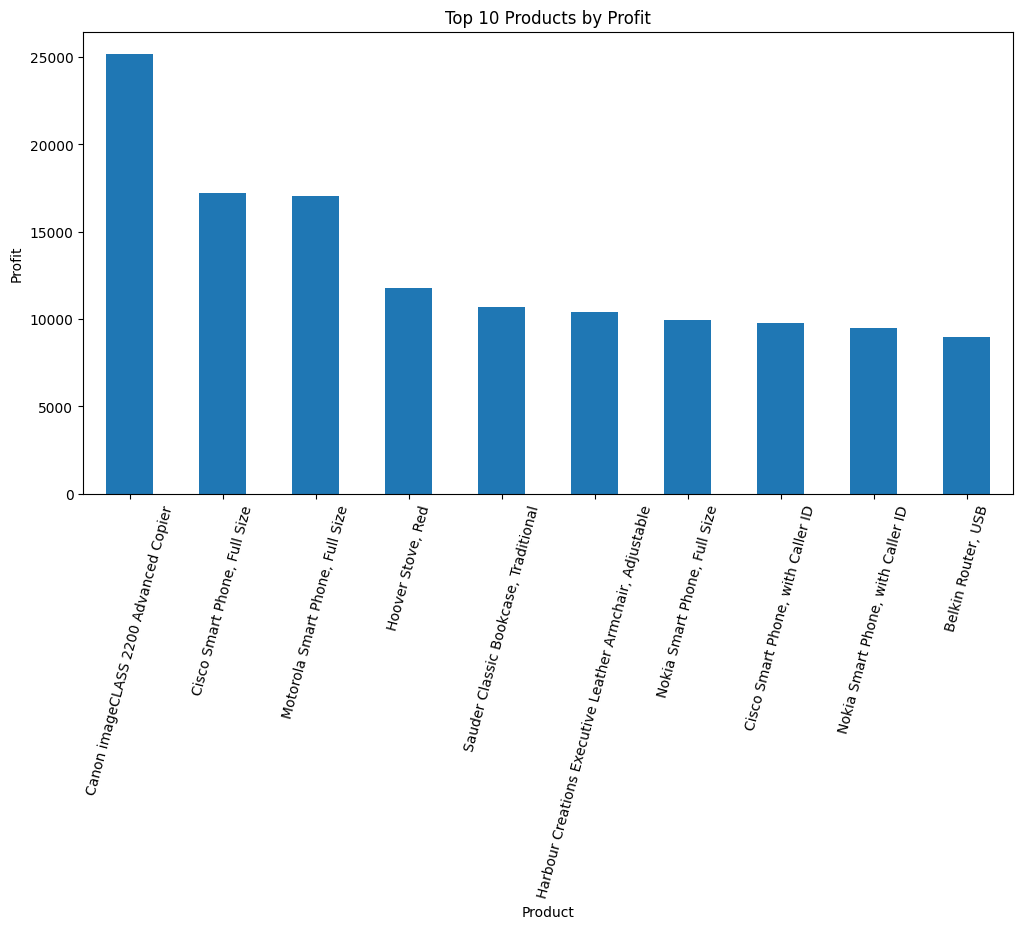

In [91]:
top_profit_products = (
    df.groupby('Product.Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_profit_products.plot(kind='bar')

plt.title('Top 10 Products by Profit')
plt.xlabel('Product')
plt.ylabel('Profit')

plt.xticks(rotation=75)
plt.show()

### Insights

- These products generate the highest profitability.
- High sales do not always mean high profit.
- These products represent the strongest value drivers for the business.

# Top 10 Loss-Making Products

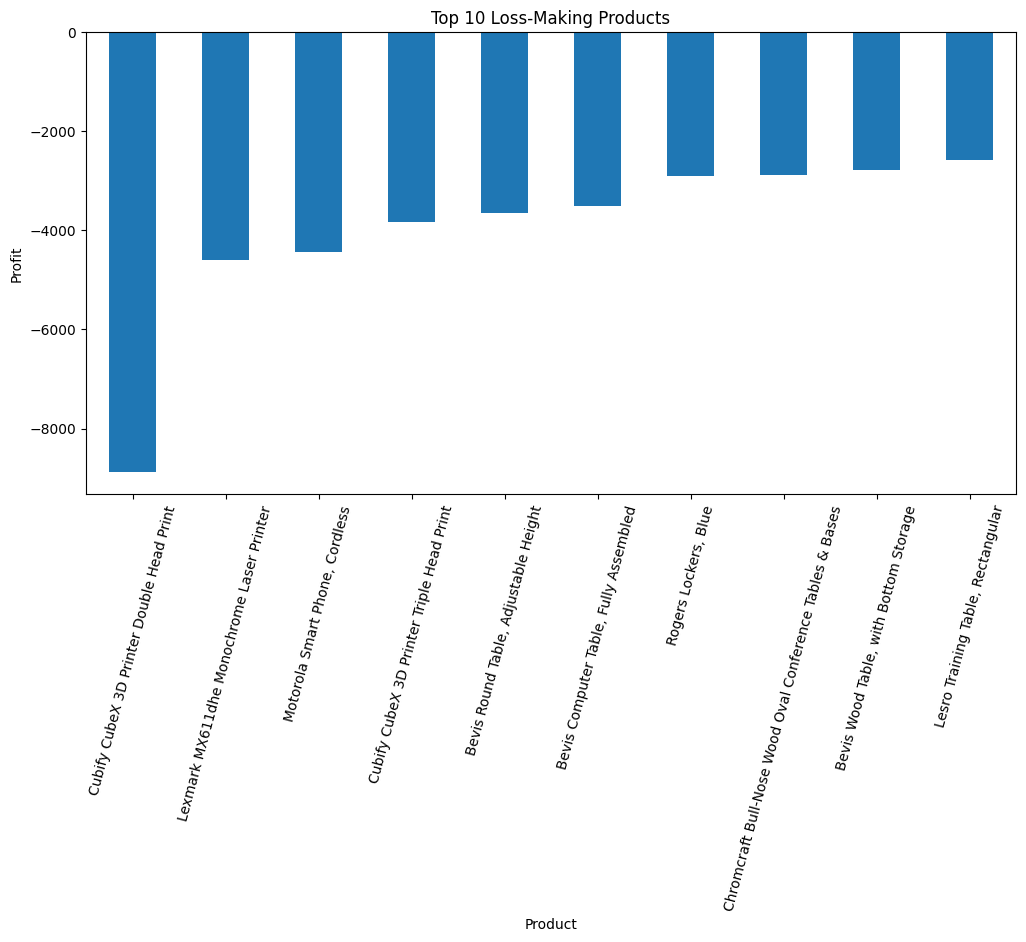

In [92]:
loss_products = (
    df.groupby('Product.Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))
loss_products.plot(kind='bar')

plt.title('Top 10 Loss-Making Products')
plt.xlabel('Product')
plt.ylabel('Profit')

plt.xticks(rotation=75)
plt.show()

### Insights

- Tables is the only sub-category with negative total profit in the current analysis.
- Loss-making products should be investigated using discount, shipping cost, product mix, and pricing data rather than assuming a single cause.
- The analysis identifies where losses occur; additional analysis is needed to determine the operational cause of each loss.

# Regional Sales Analysis

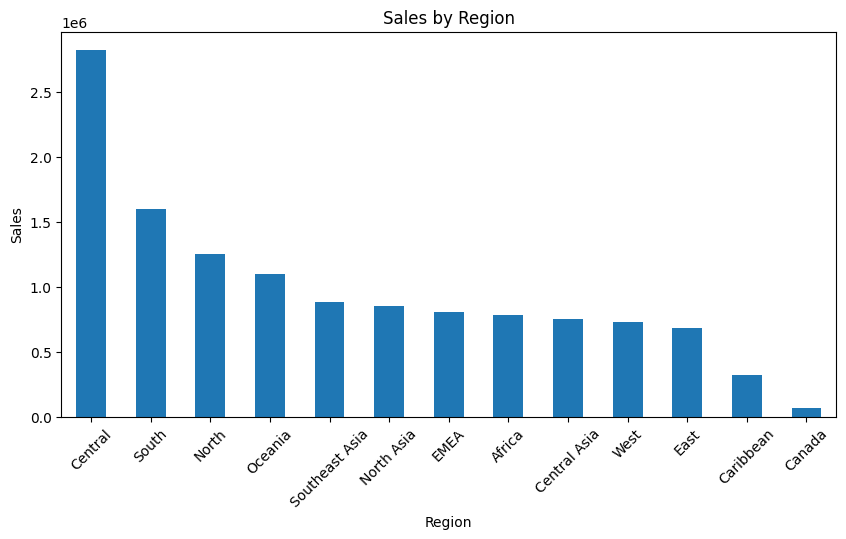

In [93]:
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.show()

### Insights

- Central recorded the highest total sales among the regions in this dataset, with approximately $2.82 million in sales.
- South was the second-highest region by total sales, while Canada recorded the lowest total sales among the listed regions.
- Regional performance differs substantially, so sales should be evaluated together with profit and profit margin rather than sales alone.

# Regional Profit Analysis

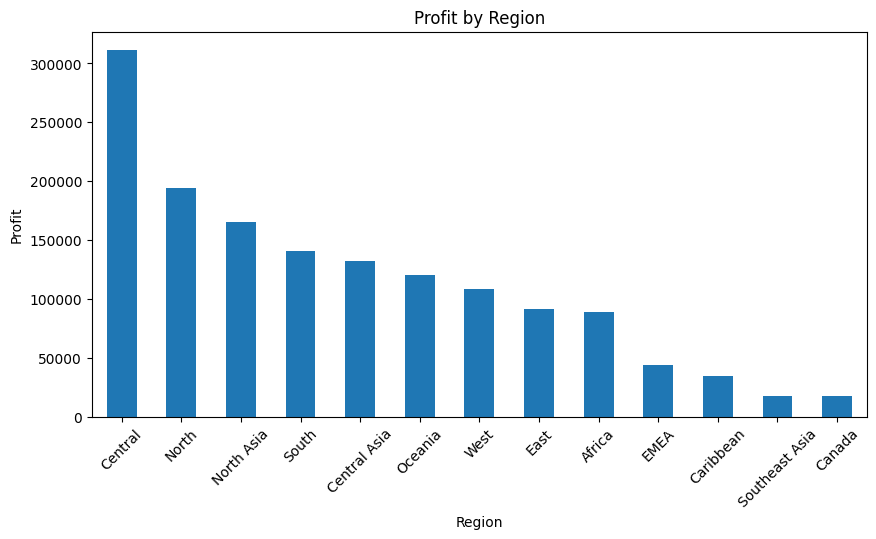

In [94]:
region_profit = (
    df.groupby('Region')['Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
region_profit.plot(kind='bar')

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.show()

### Insights

- The **West** region generated the highest total profit in the regional analysis.
- High sales do not automatically imply the same level of profitability; both sales and profit should be evaluated together.
- Regions with lower profit or margin are useful candidates for further investigation of product mix, discounting, and shipping costs.

# Top 10 States by Profit

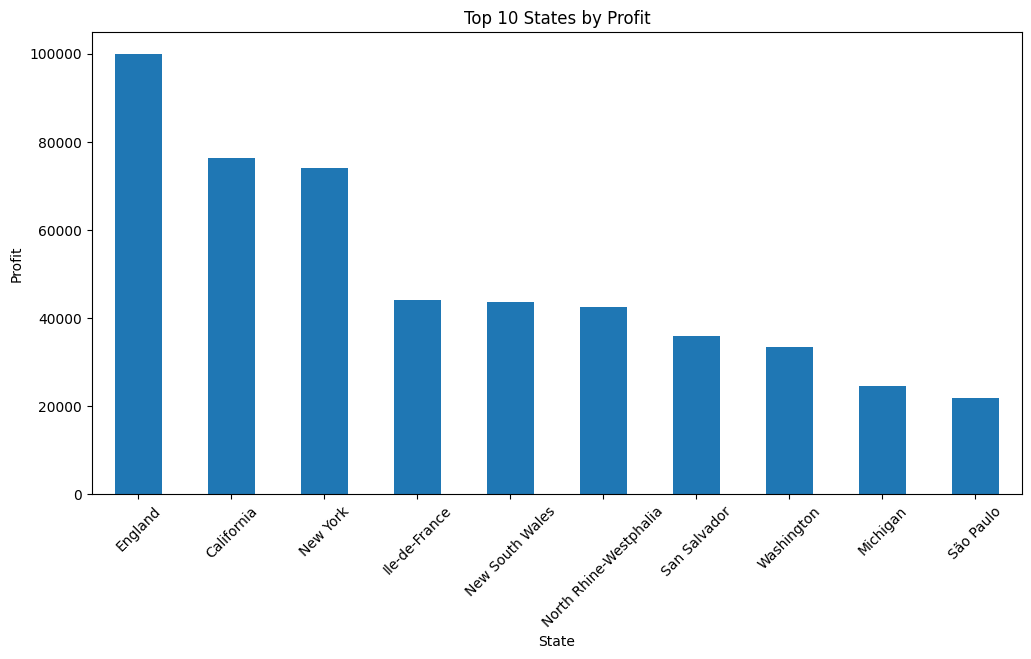

In [95]:
top_states_profit = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_states_profit.plot(kind='bar')

plt.title('Top 10 States by Profit')
plt.xlabel('State')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.show()

# Bottom 10 States by Profit

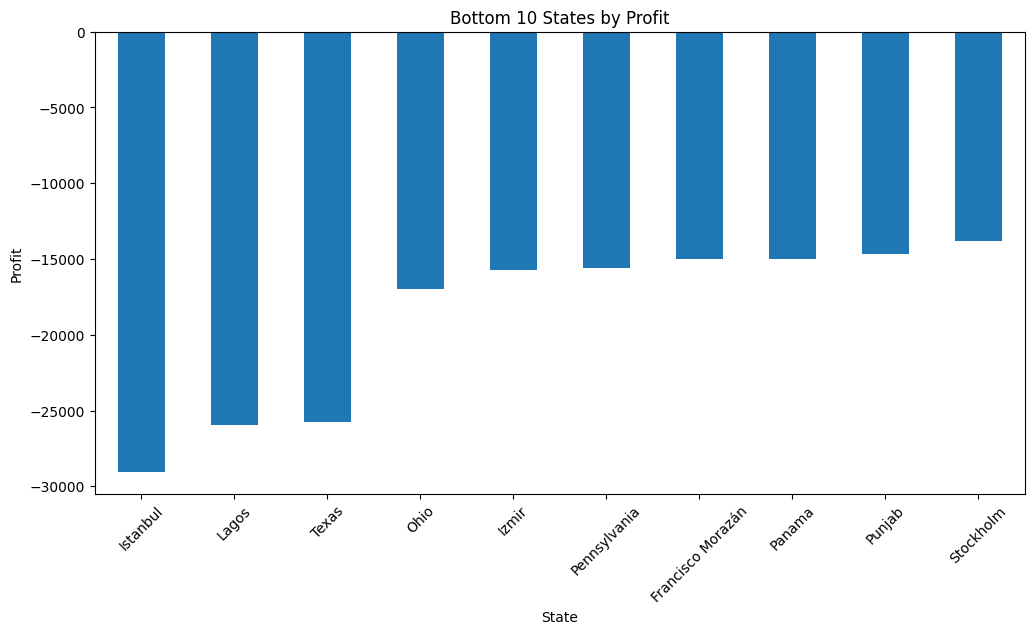

In [96]:
bottom_states_profit = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))
bottom_states_profit.plot(kind='bar')

plt.title('Bottom 10 States by Profit')
plt.xlabel('State')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.show()

### Business Implication

States with consistently negative profit are useful candidates for further investigation. Possible factors to examine include:

- Discount levels
- Shipping costs
- Product mix
- Profit margins

The dataset identifies where losses occur, but additional analysis is needed to determine the operational causes.

## Sales Analysis

In [97]:
df["Sales"].sum()

np.int64(12642905)

In [98]:
average_sales=df["Sales"].mean()
print(average_sales)

246.49844024176252


In [99]:
high_sales_category=df.groupby("Category")["Sales"].sum().idxmax()
print(high_sales_category)

Technology


In [100]:
high_sub_category_sales=df.groupby("Sub.Category")["Sales"].sum().idxmax()
print(high_sub_category_sales)

Phones


In [ ]:
# Use a weighted profit margin for each sub-category.
# This avoids the distortion caused by averaging row-level margins and
# prevents division-by-zero rows from producing +/-inf values.
subcategory_margin = df.groupby('Sub.Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
)
subcategory_margin['Profit.Margin.Pct'] = (
    subcategory_margin['Profit'] / subcategory_margin['Sales'] * 100
).round(2)

subcategory_margin.sort_values('Profit.Margin.Pct', ascending=False)

### Insight

The dataset has good data quality and is ready for business analysis. Since there are no missing values or duplicate records, the results generated from this analysis are likely to be reliable and meaningful.

In [102]:
df["Sales"].mean()

np.float64(246.49844024176252)

In [103]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64

In [104]:
df.groupby("Sub.Category")["Sales"].sum().sort_values(ascending=False).head(10)

Sub.Category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Name: Sales, dtype: int64

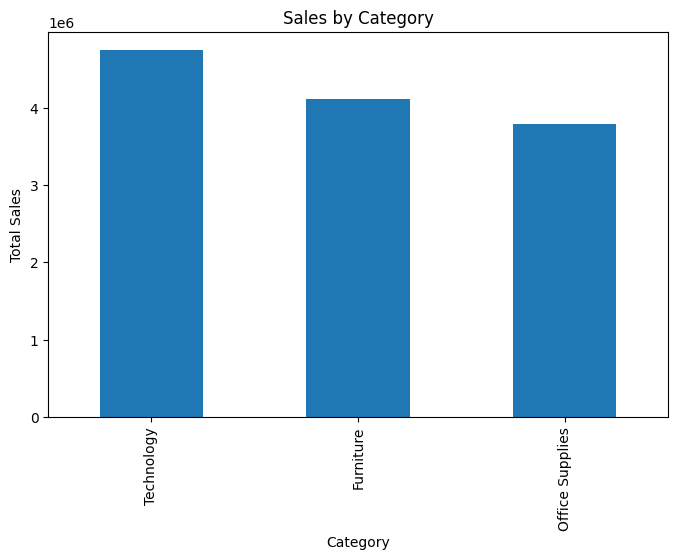

In [105]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Insight

The **Technology** category generated the highest sales among the product categories, while **Phones** generated the highest sales among sub-categories.

The **Central** region recorded the highest sales in the regional sales analysis.

These are observed patterns in this dataset. They identify high-sales categories and regions but do not, by themselves, establish customer demand, future growth, or the effect of a specific business strategy.

## Profit Analysis

In [106]:
df["Profit"].sum()

np.float64(1467457.2912800002)

In [107]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

In [108]:
df.groupby("Sub.Category")["Profit"].sum().sort_values(ascending=False)

Sub.Category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Appliances     141680.58940
Chairs         140396.26750
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: Profit, dtype: float64

In [109]:
sub_profit = df.groupby('Sub.Category')['Profit'].sum()
loss_makers = sub_profit[sub_profit < 0].sort_values()
print(sub_profit)
print(loss_makers)

Sub.Category
Accessories    129626.30620
Appliances     141680.58940
Art             57953.91090
Binders         72449.84600
Bookcases      161924.41950
Chairs         140396.26750
Copiers        258567.54818
Envelopes       29601.11630
Fasteners       11525.42410
Furnishings     46967.42550
Labels          15010.51200
Machines        58867.87300
Paper           59207.68270
Phones         216717.00580
Storage        108461.48980
Supplies        22583.26310
Tables         -64083.38870
Name: Profit, dtype: float64
Sub.Category
Tables   -64083.3887
Name: Profit, dtype: float64


In [110]:
df[['Sales','Profit','Discount','Quantity','Shipping.Cost']].corr()

,Sales,Profit,Discount,Quantity,Shipping.Cost
Sales,1.000000,0.484923,-0.086728,0.313580,0.768075
Profit,0.484923,1.000000,-0.316490,0.104365,0.354441
Discount,-0.086728,-0.316490,1.000000,-0.019875,-0.079055
Quantity,0.313580,0.104365,-0.019875,1.000000,0.272649
Shipping.Cost,0.768075,0.354441,-0.079055,0.272649,1.000000


In [111]:
region = df.groupby('Region')[['Sales','Profit']].sum()
region['Profit.Margin.Pct'] = (region['Profit'] / region['Sales'] * 100).round(2)
print(region)

                  Sales        Profit  Profit.Margin.Pct
Region                                                  
Africa           783776   88871.63100              11.34
Canada            66932   17817.39000              26.62
Caribbean        324281   34571.32104              10.66
Central         2822399  311403.98164              11.03
Central Asia     752839  132480.18700              17.60
EMEA             806184   43897.97100               5.45
East             678834   91522.78000              13.48
North           1248192  194597.95252              15.59
North Asia       848349  165578.42100              19.52
Oceania         1100207  120089.11200              10.92
South           1600960  140355.76618               8.77
Southeast Asia   884438   17852.32900               2.02
West             725514  108418.44890              14.94


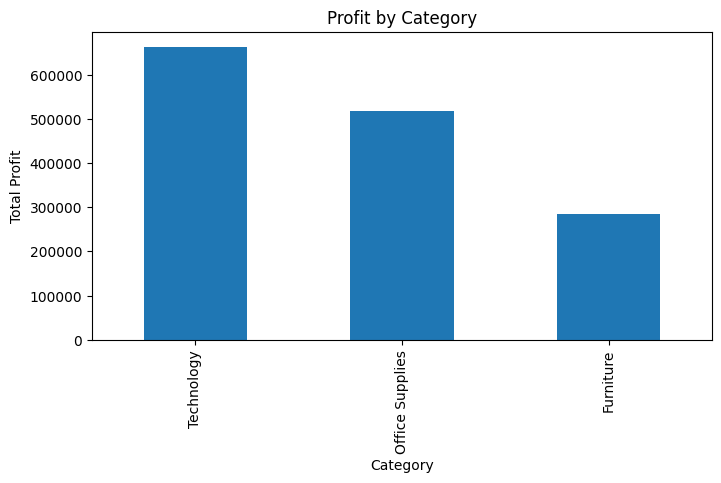

In [112]:
profit=df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

## Discount Analysis

In [113]:
most_discount_value_used=df["Discount"].max()
print(most_discount_value_used)

0.85


In [114]:
discount_profit=df.groupby("Discount")["Profit"].sum().sort_values(ascending=False)
print(discount_profit)

Discount
0.000    1.770695e+06
0.100    2.590642e+05
0.200    1.177159e+05
0.002    5.797658e+04
0.170    2.816307e+04
0.150    2.737590e+04
0.070    2.114850e+04
0.250    8.005875e+02
0.202   -5.952727e+02
0.270   -1.675079e+03
0.320   -2.391138e+03
0.850   -3.068658e+03
0.550   -3.150672e+03
0.602   -4.905419e+03
0.370   -5.806202e+03
0.650   -6.221966e+03
0.570   -6.313548e+03
0.402   -1.143045e+04
0.450   -1.360679e+04
0.350   -1.416965e+04
0.300   -1.968585e+04
0.470   -3.116225e+04
0.800   -3.861623e+04
0.400   -1.437485e+05
0.500   -1.586299e+05
0.600   -1.639547e+05
0.700   -1.863505e+05
Name: Profit, dtype: float64


The 0% discount level generated the highest aggregate profit in this dataset. The dataset also contains several non-zero discount levels with negative aggregate profit.

Because these are observational group-level results, they should be interpreted as an association between discount level and aggregate profit rather than proof that discounting itself causes the losses.

Higher discount levels are generally associated with lower aggregate profit in this dataset. The relationship should not be interpreted as causal without controlling for factors such as product mix, market, order size, and customer segment.

Discount levels of 30%, 40%, 50%, 60%, and 70% have negative aggregate profit in this dataset. This identifies discount levels that deserve further investigation; it does not by itself establish that the discount caused the loss.

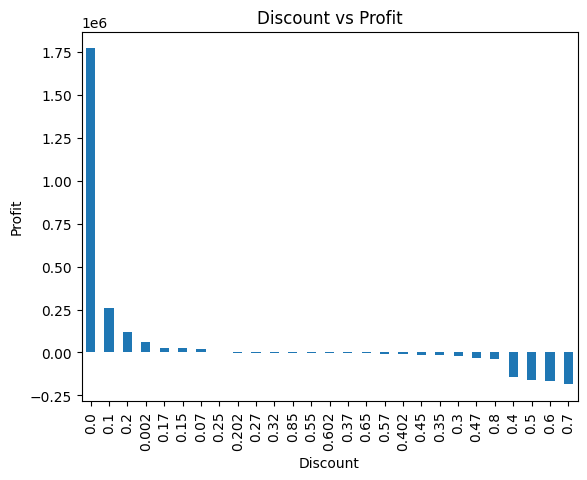

In [115]:
discount_profit.plot(kind="bar")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

### Insight

The discount analysis shows a negative association between discount level and aggregate profit. The correlation between `Discount` and `Profit` is approximately **-0.316** in the numeric correlation matrix.

Several higher discount levels also produce negative aggregate profit. However, discount level is not the only factor affecting profitability. Product mix, market, quantity, shipping cost, and customer characteristics may also contribute to the observed results.

### Business Implication

High-discount transactions should be reviewed together with product, market, and cost information before changing discount policy. The analysis supports further investigation rather than a blanket conclusion that all discounts are unprofitable.

## Country Analysis

In [116]:
high_country_sales=df.groupby("Country")["Sales"].sum().sort_values(ascending=False)
print(high_country_sales)

Country
United States        2297354
Australia             925257
France                858930
China                 700591
Germany               628857
                      ...   
Tajikistan               242
Macedonia                210
Eritrea                  188
Armenia                  156
Equatorial Guinea        150
Name: Sales, Length: 147, dtype: int64


In [ ]:
high_profit_country = df.groupby("Country")["Profit"].sum().sort_values(ascending=False)
print(high_profit_country)

The United States has the highest total sales and the highest total profit among countries in this dataset. This shows that, in this dataset, the country with the highest sales also has the highest aggregate profit.

In [118]:
lowest_country_profit = df.groupby("Country")["Profit"].sum().sort_values(ascending=True)
print(lowest_country_profit)

Country
Turkey            -98447.2320
Nigeria           -80750.7180
Netherlands       -41070.0750
Honduras          -29482.3714
Pakistan          -22446.6480
                     ...     
France            109029.0030
United Kingdom    111900.1500
India             129071.8350
China             150683.0850
United States     286397.0217
Name: Profit, Length: 147, dtype: float64


In [119]:
lowest_country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=True)
print(lowest_country_sales)

Country
Equatorial Guinea        150
Armenia                  156
Eritrea                  188
Macedonia                210
Tajikistan               242
                      ...   
Germany               628857
China                 700591
France                858930
Australia             925257
United States        2297354
Name: Sales, Length: 147, dtype: int64


The country with the lowest aggregate profit is Turkey. Turkey's negative total profit identifies a market that warrants further investigation into discounting, product mix, pricing, shipping costs, and other operational factors.

Countries should be evaluated using both sales and profitability. High-sales countries can be strong revenue contributors while still requiring margin analysis, and low-profit countries can be investigated to identify the factors associated with their results.

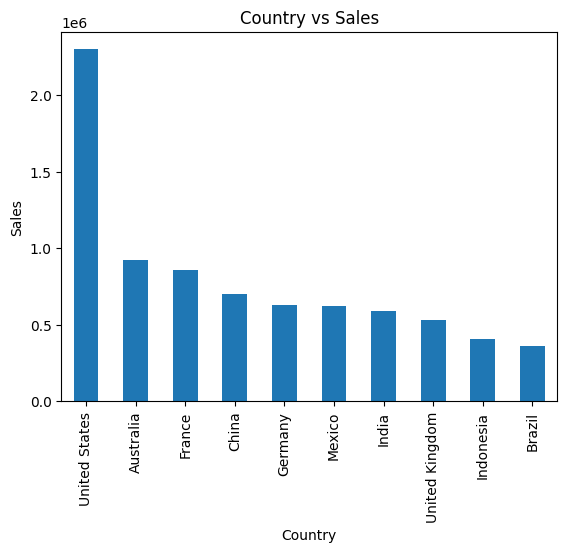

In [120]:
high_country_sales.head(10).plot(kind="bar")
plt.title("Country vs Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.show()

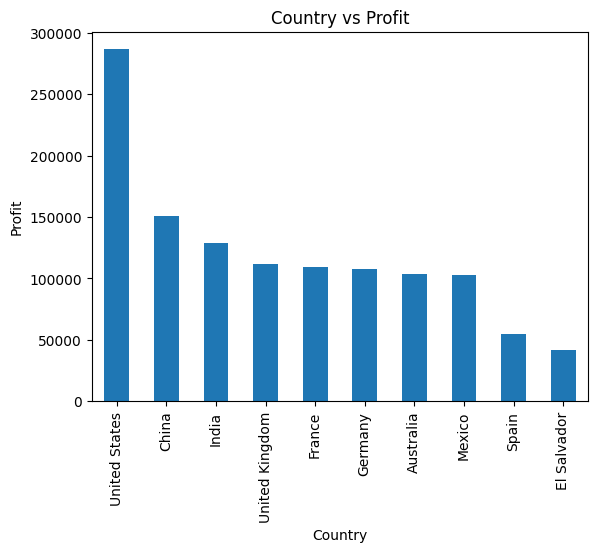

In [121]:
high_profit_country.head(10).plot(kind="bar")
plt.title("Country vs Profit")
plt.xlabel("Country")
plt.ylabel("Profit")
plt.show()


### Insight

The United States generated the highest total sales and total profit among countries in the dataset.

Equatorial Guinea recorded the lowest total sales, while Turkey recorded the lowest aggregate profit.

These are absolute country-level results. Comparing countries using profit margin, order volume, and other operational metrics would provide additional context before making market-level decisions.

## Customer Analysis

In [122]:
high_customer_sales=df.groupby("Customer.Name")["Sales"].sum().sort_values(ascending=False)
print(high_customer_sales)

Customer.Name
Tom Ashbrook           40489
Tamara Chand           37453
Greg Tran              35552
Christopher Conant     35187
Sean Miller            35170
                       ...  
Michael Oakman          5464
Sung Shariari           5331
Karen Seio              5325
Catherine Glotzbach     4116
Vivian Mathis           3891
Name: Sales, Length: 795, dtype: int64


In [123]:
high_customer_profit=df.groupby("Customer.Name")["Profit"].sum().sort_values(ascending=False)
print(high_customer_profit)

Customer.Name
Tamara Chand       8672.89890
Raymond Buch       8453.04950
Sanjit Chand       8205.37990
Hunter Lopez       7816.56778
Bill Eplett        7410.00530
                      ...    
Skye Norling      -2637.98050
Candace McMahon   -2798.79060
Grant Thornton    -3577.92306
Luke Foster       -3644.34750
Cindy Stewart     -6151.55810
Name: Profit, Length: 795, dtype: float64


The highest-sales customer is **Tom Ashbrook**, while the highest-profit customer is **Tamara Chand**. This indicates that customers who generate the most sales do not always generate the most profit. Factors such as discounts, product mix, and order costs can affect profitability, meaning high sales do not necessarily translate into high profit.

In [124]:
top10_customer_by_sales=df.groupby("Customer.Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top10_customer_by_sales)

Customer.Name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: Sales, dtype: int64


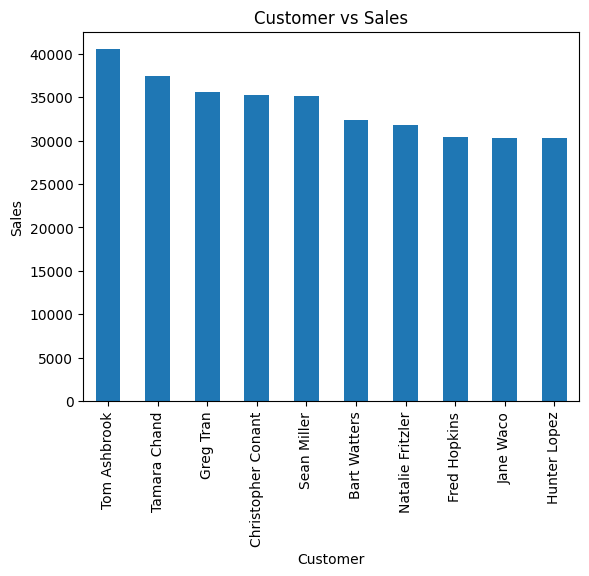

In [125]:
top10_customer_by_sales.plot(kind="bar")
plt.title("Customer vs Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")
plt.show()

In [126]:
top10_customer_by_profit=df.groupby("Customer.Name")["Profit"].sum().sort_values(ascending=False).head(10)
print(top10_customer_by_profit)

Customer.Name
Tamara Chand       8672.89890
Raymond Buch       8453.04950
Sanjit Chand       8205.37990
Hunter Lopez       7816.56778
Bill Eplett        7410.00530
Harry Marie        6958.28640
Susan Pistek       6484.40726
Mike Gockenbach    6458.67620
Adrian Barton      6417.28450
Tom Ashbrook       6311.97910
Name: Profit, dtype: float64


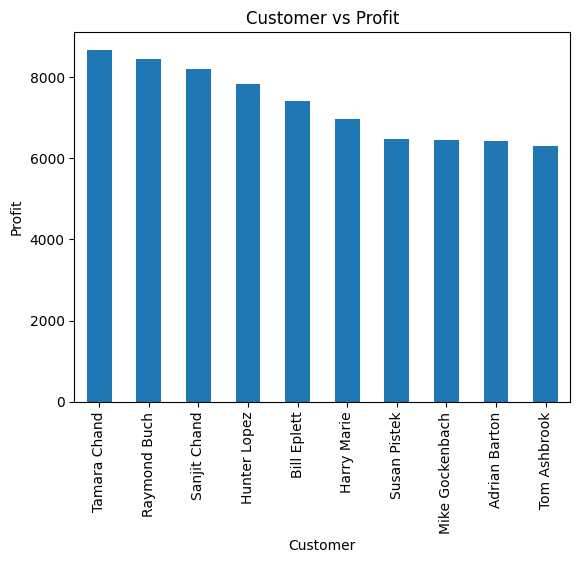

In [127]:
top10_customer_by_profit.plot(kind="bar")
plt.title("Customer vs Profit")
plt.xlabel("Customer")
plt.ylabel("Profit")
plt.show()

In [128]:
high_customer_profit=df.groupby("Customer.Name")["Profit"].sum().sort_values(ascending=False)
print(high_customer_profit)

Customer.Name
Tamara Chand       8672.89890
Raymond Buch       8453.04950
Sanjit Chand       8205.37990
Hunter Lopez       7816.56778
Bill Eplett        7410.00530
                      ...    
Skye Norling      -2637.98050
Candace McMahon   -2798.79060
Grant Thornton    -3577.92306
Luke Foster       -3644.34750
Cindy Stewart     -6151.55810
Name: Profit, Length: 795, dtype: float64


Yes, there are customers generating negative profit. This indicates that the company is losing money on certain customer relationships, possibly due to high discounts, low-margin products, or operational costs. These customers should be analyzed further to improve profitability.

In [129]:
customer_sales = (

    df.groupby('Customer.Name')['Sales']

    .sum()

)
customer_sales.describe()

count      795.000000
mean     15903.025157
std       5209.800805
min       3891.000000
25%      12242.500000
50%      15258.000000
75%      18770.500000
max      40489.000000
Name: Sales, dtype: float64

In [130]:
customer_sales = customer_sales.reset_index()
customer_sales['Segment'] = pd.qcut(

    customer_sales['Sales'],

    q=3,

    labels=['Low Value', 'Medium Value', 'High Value']

)

customer_sales['Segment'].value_counts()

Segment
Low Value       265
Medium Value    265
High Value      265
Name: count, dtype: int64

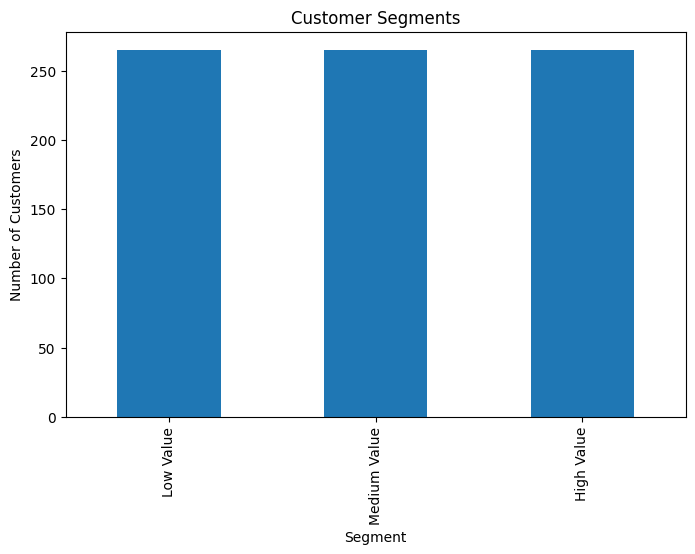

In [131]:
customer_sales['Segment'].value_counts().plot(
    kind='bar',

    figsize=(8,5)
)
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()



### Business Insights

The customer analysis shows differences between customers based on sales and profit contribution.

- Customers can be grouped into low-, medium-, and high-value segments using the analysis performed in the notebook.
- High-value customers contribute a larger share of total sales.
- The highest-sales customer is not necessarily the highest-profit customer.

These results support evaluating customers using both sales and profitability rather than assuming that higher revenue always means higher business value.

# Shipping Mode Analysis

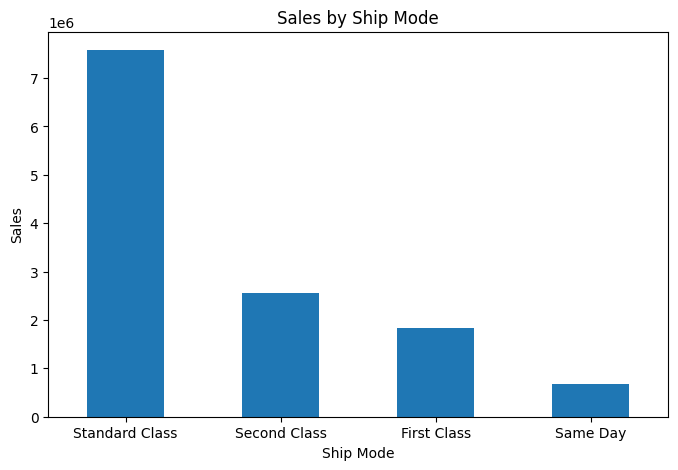

In [132]:
ship_sales = (
    df.groupby('Ship.Mode')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
ship_sales.plot(kind='bar')

plt.title('Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Sales')

plt.xticks(rotation=0)
plt.show()

### Insights

- Shipping modes differ in their sales and profit contribution.
- Comparing sales and profit by shipping mode helps identify cases where higher sales do not necessarily correspond to higher profitability.
- Shipping-mode results should be interpreted together with shipping cost and order characteristics rather than treated as direct evidence of customer preference or demand.

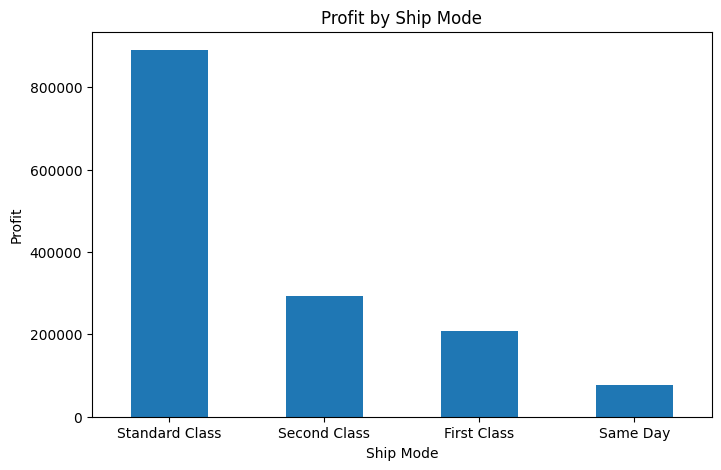

In [133]:
ship_profit = (
    df.groupby('Ship.Mode')['Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
ship_profit.plot(kind='bar')

plt.title('Profit by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Profit')

plt.xticks(rotation=0)
plt.show()

### Business Insights

- Some shipping modes may generate higher sales while contributing differently to profit.
- Shipping cost is positively associated with sales in the correlation analysis, but this does not establish that shipping cost causes higher sales.
- Shipping performance should therefore be evaluated using both sales and profit, together with the underlying order mix.

# Correlation Analysis

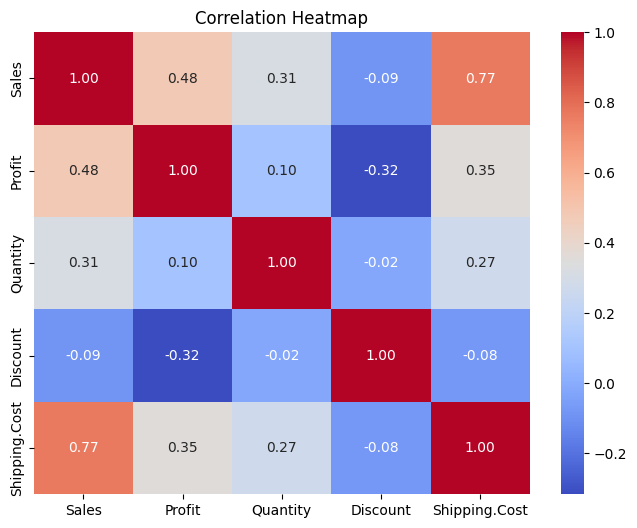

In [134]:
correlation_matrix = df[
    ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping.Cost']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

### Insights

The correlation matrix shows several notable relationships:

- **Sales and Shipping Cost:** 0.768 — a strong positive association in this dataset.
- **Sales and Profit:** 0.485 — a moderate positive association.
- **Profit and Discount:** -0.316 — a moderate negative association.
- **Sales and Quantity:** 0.314 — a positive association.

These values describe linear associations between the variables. They do not establish causation. For example, the negative correlation between discount and profit does not by itself prove that discounts cause lower profit.

### Business Recommendation

Use both revenue and profit when evaluating customers and products. Customers with high sales but low or negative profit should be investigated for factors such as discount levels, product mix, and shipping costs.

Similarly, loss-making products and high-discount transactions should be examined at a more granular level before changing pricing or discount policies.

### Insight

Tom Ashbrook generated the highest sales, while Tamara Chand generated the highest profit. This demonstrates that the customer with the highest revenue contribution is not necessarily the customer with the highest profit contribution.

The presence of customers with negative aggregate profit also shows why customer evaluation should consider both sales and profitability.

In [135]:
high_sales_year=df.groupby("Year")["Sales"].sum().sort_values(ascending=False)
print(high_sales_year)

Year
2014    4300041
2013    3405860
2012    2677493
2011    2259511
Name: Sales, dtype: int64


Total sales increased from approximately **$2.26M in 2011** to **$4.30M in 2014**.

This is an observed upward trend in the dataset. It shows that recorded sales increased over the period, but the analysis alone does not establish the reasons for that increase or whether it represents broader customer-demand growth.

In [136]:
high_profit_years=df.groupby("Year")["Profit"].sum().sort_values(ascending=False)
print(high_profit_years)

Year
2014    504165.97046
2013    406935.23018
2012    307415.27910
2011    248940.81154
Name: Profit, dtype: float64


Profit increased steadily from **2011 to 2014**. The company's profit rose from approximately 248,941 in 2011 to 504,166 in 2014, showing that the business not only increased sales but also improved overall profitability.

In [137]:
yearly_sales = df.groupby('Year')['Sales'].sum()
yoy_growth = yearly_sales.pct_change() * 100
print(yoy_growth.round(2))

Year
2011      NaN
2012    18.50
2013    27.20
2014    26.25
Name: Sales, dtype: float64


In [138]:
df['Month'] = df['Order.Date'].dt.month
monthly = df.groupby(['Year','Month'])['Sales'].sum().unstack()
print(monthly)

Month      1       2       3       4       5       6       7       8       9   \
Year                                                                            
2011    98902   91152  145726  116927  146762  215214  115518  207570  290230   
2012   135775  100521  163092  161060  208370  256181  145247  303158  289390   
2013   199197  167247  198591  177835  260525  396513  229940  326491  376626   
2014   241267  184848  263110  242781  288404  401843  258718  456633  481186   

Month      10      11      12  
Year                           
2011   199070  298499  333941  
2012   252942  323512  338245  
2013   293423  373996  405476  
2014   422785  555312  503154  


In [139]:
df['Quarter'] = df['Order.Date'].dt.quarter
df.groupby(['Year','Quarter'])['Sales'].sum().unstack()


Quarter,1,2,3,4
Year,,,,
2011,335780,478903,613318,831510
2012,399388,625611,737795,914699
2013,565035,834873,933057,1072895
2014,689225,933028,1196537,1481251


In [140]:
df['Shipping.Days'] = (df['Ship.Date'] - df['Order.Date']).dt.days
df.groupby('Ship.Mode')['Shipping.Days'].mean().round(2)

Ship.Mode
First Class       2.18
Same Day          0.04
Second Class      3.23
Standard Class    5.00
Name: Shipping.Days, dtype: float64

### Insight

The analysis shows an upward trend in both sales and profit from 2011 to 2014. Sales increased from approximately **$2.26M to $4.30M**, while profit increased from approximately **$248.94K to $504.17K**.

These figures describe the observed financial trend in the dataset. They do not by themselves establish successful business expansion, increased customer demand, or the causes of the growth.

## Market Analysis

In [141]:
high_market_sales=df.groupby("Market")["Sales"].sum().sort_values(ascending=False)
print(high_market_sales)

Market
APAC      3585833
EU        2938139
US        2297354
LATAM     2164687
EMEA       806184
Africa     783776
Canada      66932
Name: Sales, dtype: int64


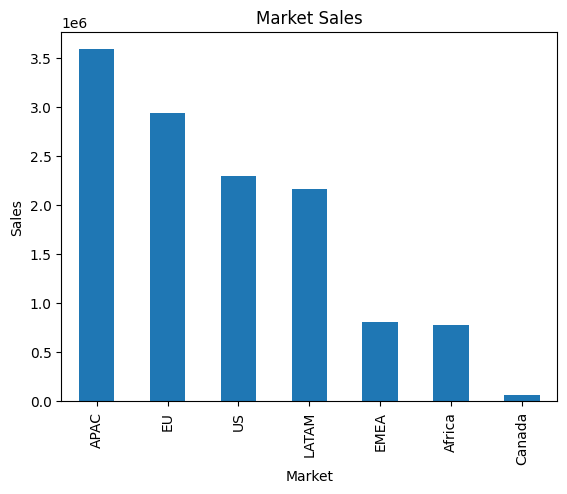

In [142]:
high_market_sales.head(10).plot(kind="bar")
plt.title("Market Sales")
plt.xlabel("Market")
plt.ylabel("Sales")
plt.show()

In [143]:
high_market_profit=df.groupby("Market")["Profit"].sum().sort_values(ascending=False)
print(high_market_profit)

Market
APAC      436000.04900
EU        372829.74150
US        286397.02170
LATAM     221643.48708
Africa     88871.63100
EMEA       43897.97100
Canada     17817.39000
Name: Profit, dtype: float64


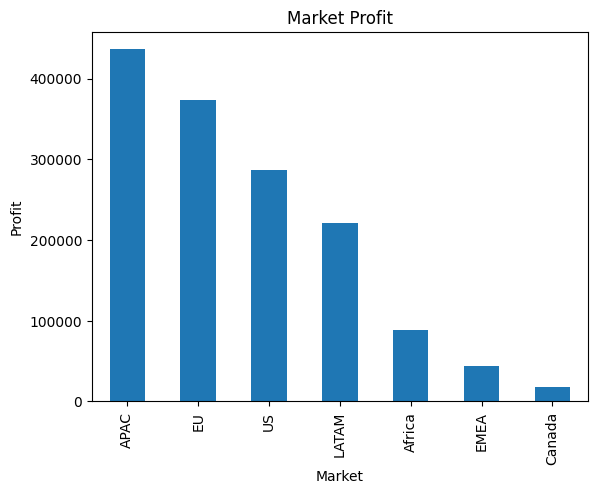

In [144]:
high_market_profit.head(10).plot(kind="bar")
plt.title("Market Profit")
plt.xlabel("Market")
plt.ylabel("Profit")
plt.show()

### Insight

High-sales markets also recorded high aggregate profit in this dataset. This indicates that sales and profit are both concentrated in some of the same markets.

However, aggregate sales alone do not explain why markets differ in profitability. Market-level margins and other operational factors should be considered before drawing broader business conclusions.

In [145]:
lowest_profit_market=df.groupby("Market")["Profit"].sum().sort_values(ascending=True)
print(lowest_profit_market)

Market
Canada     17817.39000
EMEA       43897.97100
Africa     88871.63100
LATAM     221643.48708
US        286397.02170
EU        372829.74150
APAC      436000.04900
Name: Profit, dtype: float64


In [146]:
market_profit = df.groupby("Market")["Profit"].sum()

print("Market:", market_profit.idxmin())
print("Profit:", market_profit.min())

Market: Canada
Profit: 17817.39


### Market Observation

**APAC** recorded the highest aggregate sales and aggregate profit among the listed markets in this dataset.

This identifies APAC as a high-performing market by absolute sales and profit. It does **not** establish that APAC should receive more investment or that it has the highest growth potential. Further comparison using profit margin, growth, customer mix, discounting, and operating costs would be needed before making resource-allocation decisions.

## Conclusion

This project analyzed the Global Superstore dataset to uncover insights related to sales, profit, customers, products, discounts, markets, and business performance over time.

The analysis found that **Technology** generated the highest total profit among the three categories, while **Tables** was the only sub-category with negative total profit. The United States generated the highest total sales and total profit among countries, while APAC generated the highest aggregate sales and profit among the listed markets.

Discount analysis showed a negative association between discount level and aggregate profit, including negative aggregate profit at several higher discount levels. This relationship is observational and should not be interpreted as proof that discounting alone causes lower profit.

Customer analysis showed that the highest-sales customer was not the highest-profit customer, reinforcing the importance of evaluating both revenue and profitability. Correlation analysis also highlighted relationships between sales, profit, discount, quantity, and shipping cost.

Overall, the project identifies the main areas that warrant further business investigation: loss-making sub-categories, high-discount transactions, customer profitability, and market-level margins. These findings provide a basis for deeper analysis rather than assuming a single cause for business performance differences.